# LOAD LIBRARIES

In [1]:

import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
from scipy.stats import lognorm 
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet

Custom plotting function

In [2]:
def plot_data_grid(indat, ncols=3):
    vars = indat.columns
    nrows = (len(vars) + ncols - 1) // ncols  # Calculate the number of rows needed
    relative_markersize = max(1, 10 / len(vars))  # Scale marker size inversely to the number of plots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), constrained_layout=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    
    for ax, var in zip(axes, vars):
        ax.plot(indat[var], marker='o', markersize=relative_markersize, label=var)
        ax.set_xlabel('Time')
        ax.set_ylabel(var)
        ax.tick_params(axis='x', rotation=45)
        ax.legend()
    
    # Remove any unused subplots
    for ax in axes[len(vars):]:
        fig.delaxes(ax)
    
    plt.show()

# READ DATA

## FLUXES

Loaded .parquet file ../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (1.303 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


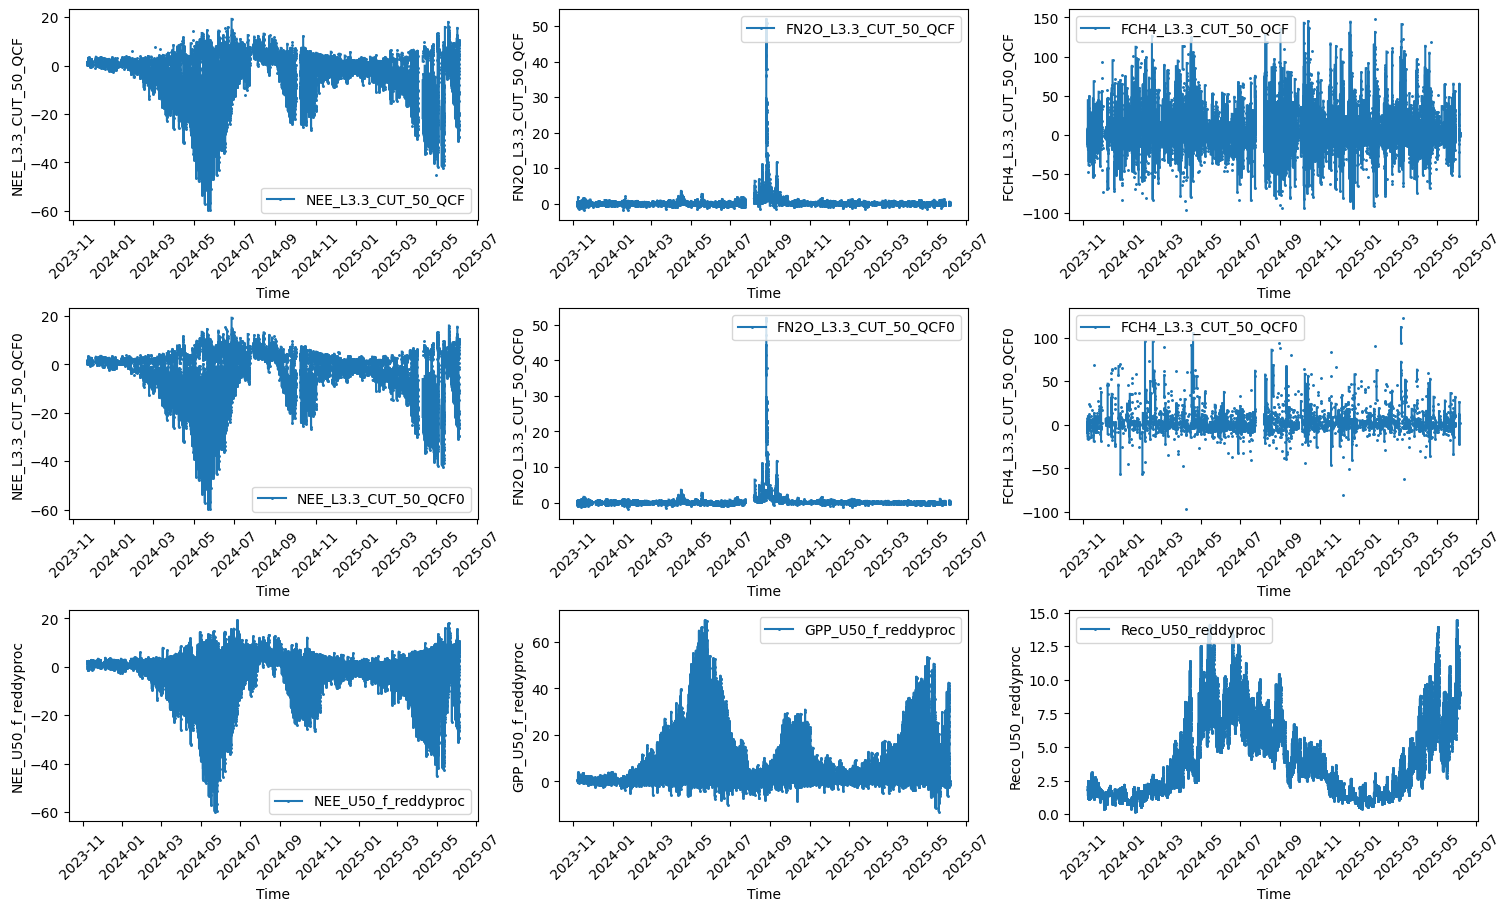

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty
TIMESTAMP_MIDDLE,,,,,,,,,,,
2023-11-07 15:45:00,NaN,NaN,NaN,NaN,NaN,NaN,1.406032,0.608764,2.014795,B,uncertain
2023-11-07 16:15:00,NaN,0.324973,-4.360399,NaN,0.324973,NaN,1.626907,0.379030,2.005937,B,uncertain
2023-11-07 16:45:00,NaN,0.053551,NaN,NaN,0.053551,NaN,2.239952,-0.251680,1.988271,buffer,None
2023-11-07 17:15:00,NaN,0.339963,2.488800,NaN,0.339963,2.488800,2.205842,-0.291887,1.913955,B,certain
2023-11-07 17:45:00,NaN,-0.983566,-9.177059,NaN,-0.983566,-9.177059,2.205842,-0.287550,1.918292,B,certain
...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 22:45:00,10.095010,-0.069384,2.160966,10.095010,-0.069384,2.160966,10.095010,-1.089414,9.005596,B,certain
2025-06-04 23:15:00,8.641342,-0.288296,-1.904577,8.641342,-0.288296,NaN,8.641342,0.341996,8.983338,B,certain
2025-06-04 23:45:00,8.664543,0.220511,NaN,8.664543,0.220511,NaN,8.664543,0.195977,8.860520,B,certain


In [3]:
fluxes = load_parquet(filepath=r"../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")

qcf_cols = [c for c in fluxes.columns if c.endswith('CUT_50_QCF')]
qcf0_cols = [c for c in fluxes.columns if c.endswith('CUT_50_QCF0')]
reddyproc_cols = ['NEE_U50_f_reddyproc',
                'GPP_U50_f_reddyproc',
                'Reco_U50_reddyproc']
cols = qcf_cols + qcf0_cols + reddyproc_cols + ['parcel', 'parcel_certainty']

fluxes = fluxes[cols].copy()

# plots
indat = fluxes.drop(columns=['parcel', 'parcel_certainty'])
plot_data_grid(indat, ncols=3)

# show data
fluxes

## METEO

Bulk density data used for WFPS calculation was measured on May 2025.
See file CH-TAN_20250520_soil_bulk_density.xlsx

Loaded .parquet file ../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.184 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


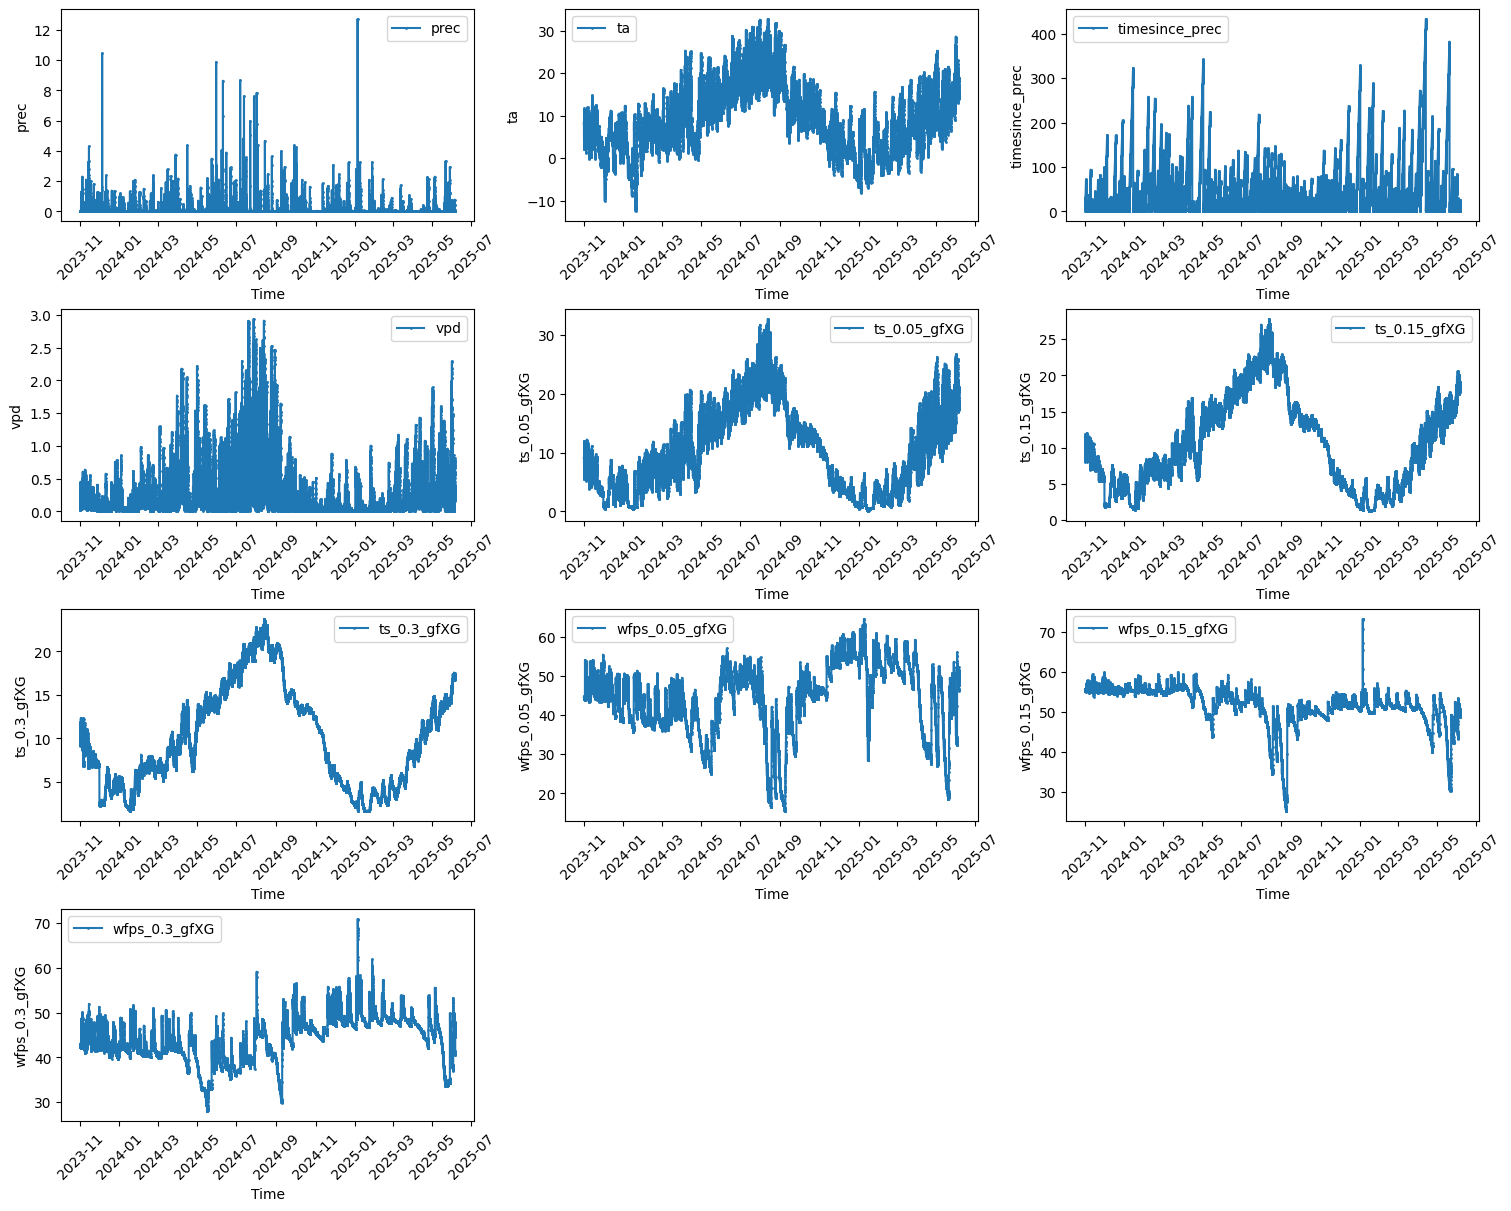

,prec,ta,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG
TIMESTAMP_MIDDLE,,,,,,,,,,
2023-10-31 23:45:00,0.0,8.000000,1,0.216913,9.098388,11.378627,11.530369,44.506302,55.538911,42.353099
2023-11-01 00:15:00,0.0,8.633333,2,0.272054,9.154857,11.409856,11.225279,44.507284,55.221947,42.530532
2023-11-01 00:45:00,0.0,8.266667,3,0.257705,9.216592,11.371663,11.158751,44.466206,55.137338,42.519273
2023-11-01 01:15:00,0.0,6.966667,4,0.171078,9.287736,11.434952,11.346931,44.482367,55.254504,42.686566
2023-11-01 01:45:00,0.0,5.666667,5,0.104550,9.090844,11.641592,11.395833,44.505722,55.255965,42.709687
...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,0.0,15.833333,22,0.285270,18.565866,18.817616,17.117313,47.661621,48.667096,41.341274
2025-06-05 22:15:00,0.0,15.733333,23,0.289417,18.389761,18.866354,16.990484,46.519816,48.765574,40.453896
2025-06-05 22:45:00,0.0,16.200000,24,0.404542,18.252666,18.519451,17.198946,46.053434,48.760014,40.437537


In [4]:
meteo = load_parquet(filepath=r"../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")


cols =['prec',
       'ta',
       'timesince_prec', 
       'vpd',
       'ts_0.05_gfXG',
       'ts_0.15_gfXG', 
       'ts_0.3_gfXG',
       'swc_0.05_gfXG',
       'swc_0.15_gfXG',
       'swc_0.3_gfXG']

meteo = meteo[cols]

# Calculate WFPS from SWC using formula with bulk density and particle density
bulk_density = {
    '0.05': 1.1, 
    '0.15': 1.1, 
    '0.3': 1.2, 
}

# Standard particle density since it was not measured
particle_density = 2.65

# Iterate over SWC columns and compute WFPS
swc_cols = [col for col in meteo if col.startswith('swc_')]
for col in swc_cols:
    new_name = col.replace('swc', 'wfps')
    for depth, bd in bulk_density.items():
        if depth in col:
            # calculate wfps for current depth
            wfps = meteo[col] / (1 - (bd / particle_density)) # no need to multiply by 100 because swc is in percent
            meteo[new_name] = wfps
            break

# Now we can remove all the swc columns from which we calculated wfps
meteo.drop(columns=swc_cols, inplace=True)

# plots
plot_data_grid(meteo, ncols=3)

# show data
meteo

## MANAGEMENT

Loaded .parquet file ../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet (0.089 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


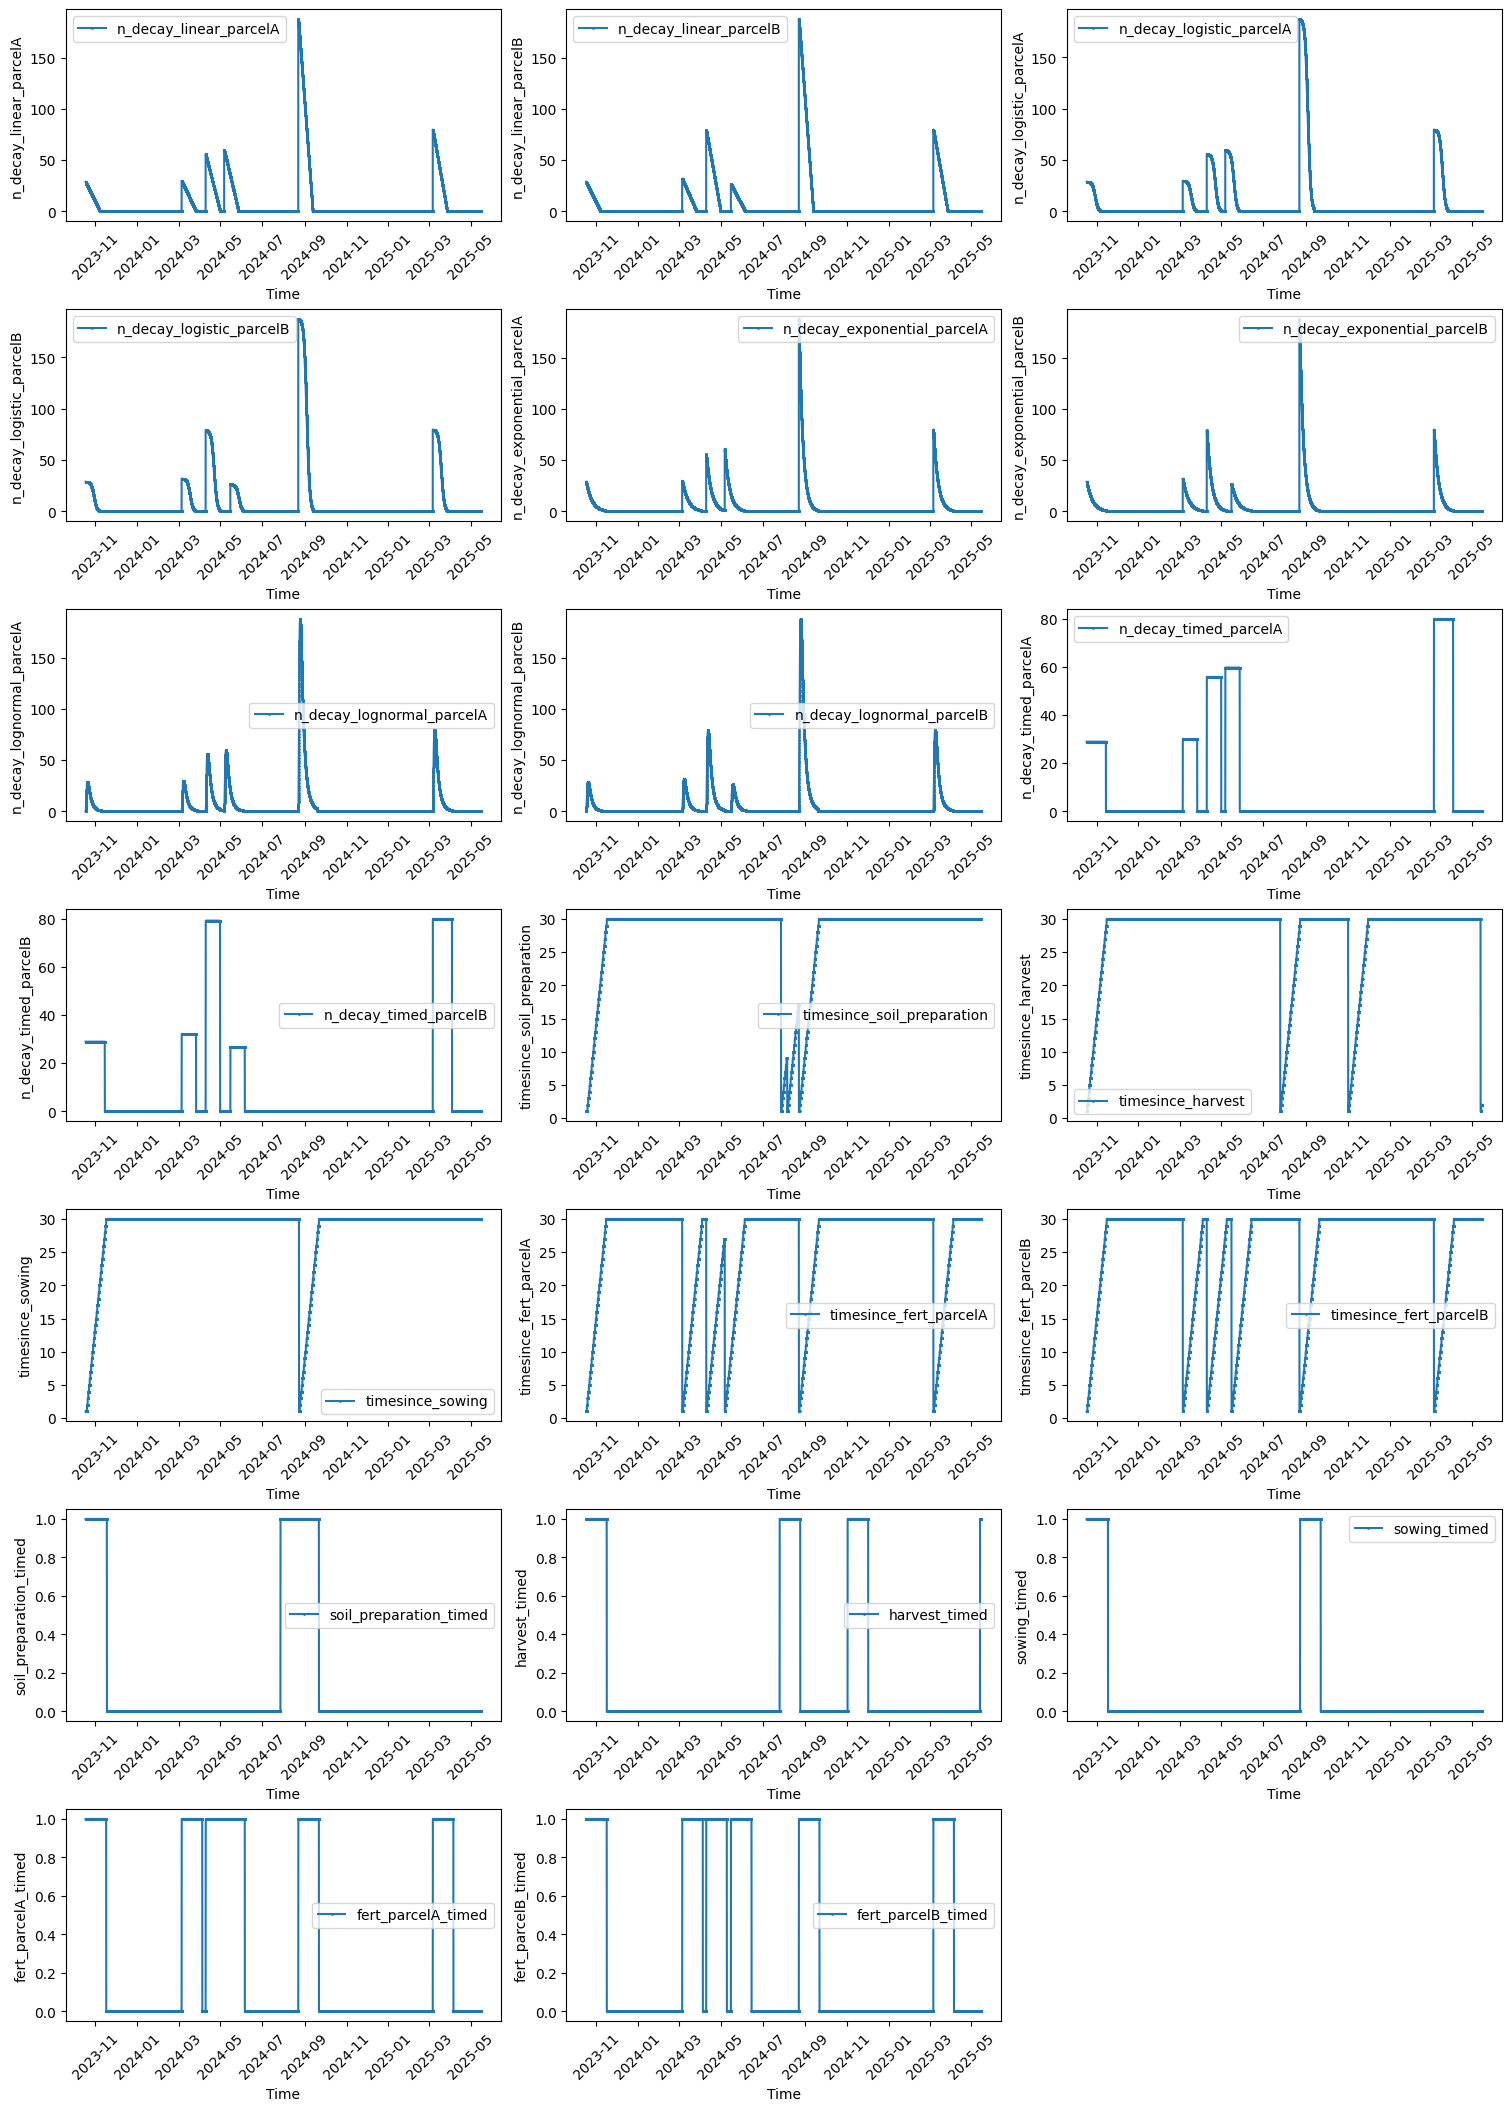

,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,soil_preparation_timed,harvest_timed,sowing_timed,fert_parcelA_timed,fert_parcelB_timed
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,29.000000,29.000000,28.908905,28.908905,29.000000,29.000000,2.808299e-07,2.808299e-07,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 12:45:00,28.971230,28.971230,28.907992,28.907992,28.927434,28.927434,3.727140e-05,3.727140e-05,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 13:15:00,28.942460,28.942460,28.907070,28.907070,28.855049,28.855049,4.592764e-04,4.592764e-04,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 13:45:00,28.913690,28.913690,28.906140,28.906140,28.782845,28.782845,2.334962e-03,2.334962e-03,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 14:15:00,28.884921,28.884921,28.905199,28.905199,28.710822,28.710822,7.540160e-03,7.540160e-03,29.0,29.0,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15 10:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,30,2,30,30,30,0,1,0,0,0
2025-05-15 10:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,30,2,30,30,30,0,1,0,0,0
2025-05-15 11:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,30,2,30,30,30,0,1,0,0,0


In [5]:
management = load_parquet(filepath=r"../20_MANAGEMENT/21.1_mgmt_full_timestamp.parquet")

# select subset of columns
cols = [c for c in management.columns if 
                c.startswith('n_decay') or
                c.startswith('timesince') or
                c.endswith('timed')]
management = management[cols]

# plots
plot_data_grid(management, ncols=3)

# show data
management

# MERGE DATA

## MERGE

In [6]:
df = pd.concat([fluxes, meteo, management], axis=1)

## SANITIZE TIMESTAMP

In [7]:
# Remove duplicates, keep first
locs_duplicates = df.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
df = df[~locs_duplicates]

# Remove NaTs
locs_nats = df.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
df = df[~locs_nats]

# Sort timestamp index
df = df.sort_index(ascending=True)

df

Found duplicates in index: 0
Found NaTs in index: 0


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,...,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,soil_preparation_timed,harvest_timed,sowing_timed,fert_parcelA_timed,fert_parcelB_timed
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.000000,2.808299e-07,2.808299e-07,29.0,29.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-17 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.927434,3.727140e-05,3.727140e-05,29.0,29.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-17 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.855049,4.592764e-04,4.592764e-04,29.0,29.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-17 13:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.782845,2.334962e-03,2.334962e-03,29.0,29.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2023-10-17 14:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,28.710822,7.540160e-03,7.540160e-03,29.0,29.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,15.833333,22.0,0.285270,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,15.733333,23.0,0.289417,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.200000,24.0,0.404542,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns

Index(['NEE_L3.3_CUT_50_QCF', 'FN2O_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0', 'FN2O_L3.3_CUT_50_QCF0', 'FCH4_L3.3_CUT_50_QCF0', 'NEE_U50_f_reddyproc', 'GPP_U50_f_reddyproc', 'Reco_U50_reddyproc', 'parcel', 'parcel_certainty', 'prec', 'ta', 'timesince_prec', 'vpd', 'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_soil_preparation', 'timesince_harvest', 'timesince_sowing', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'soil_preparation_timed', 'harvest_timed', 'sowing_timed', 'fert_parcelA_timed', 'fert_parcelB_timed'], dtype='object')

# MERGE PARCEL-SPECIFIC COLS

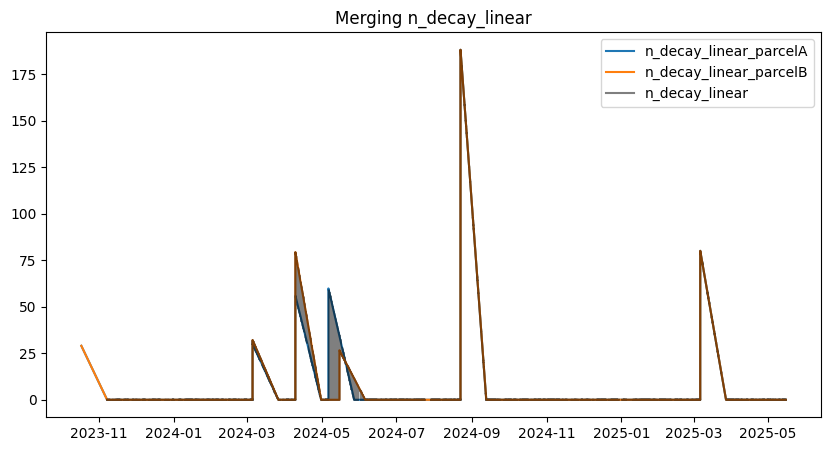

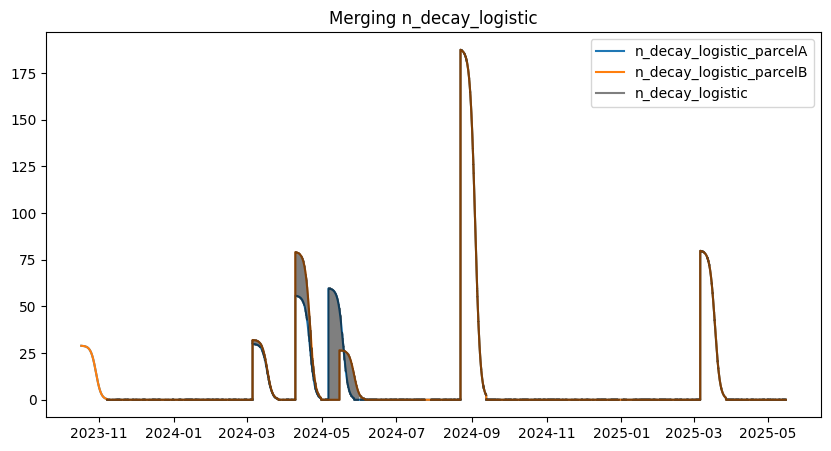

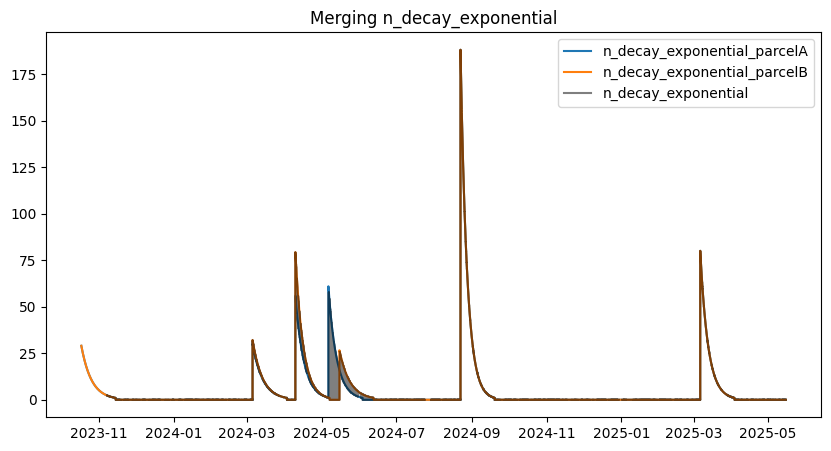

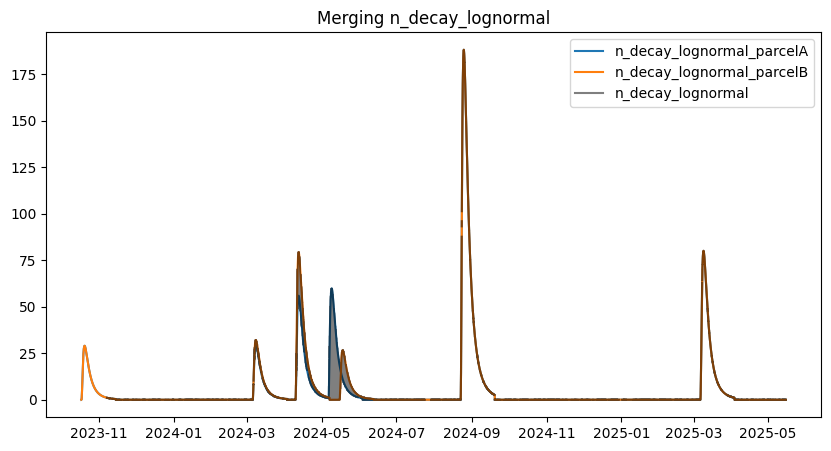

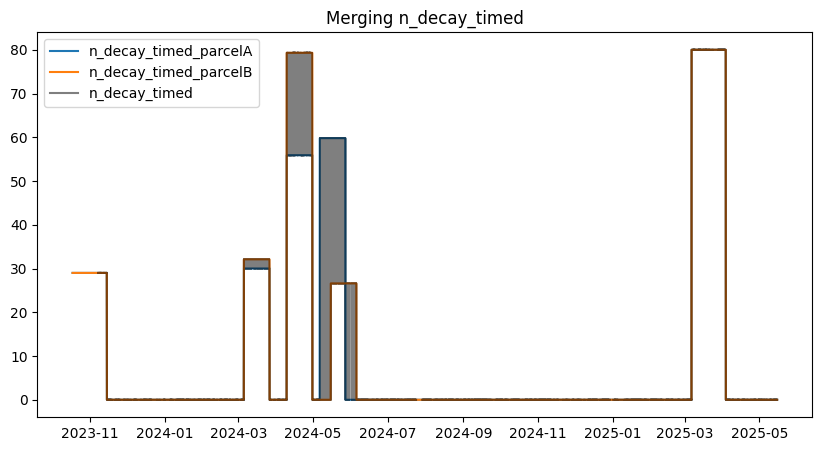

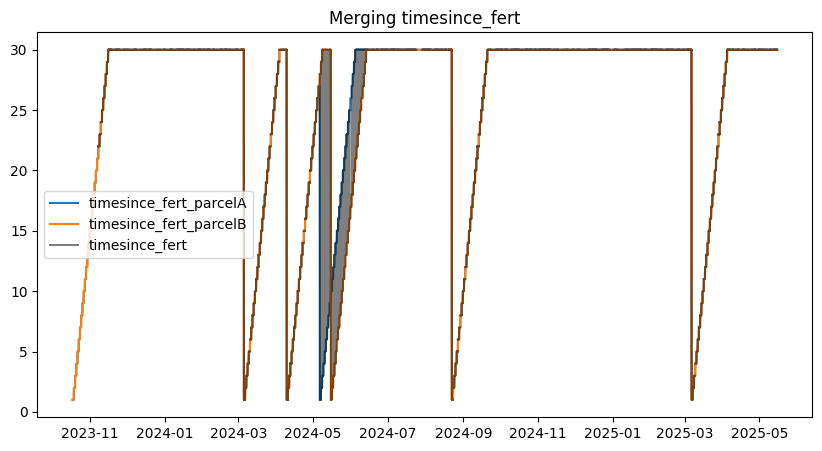

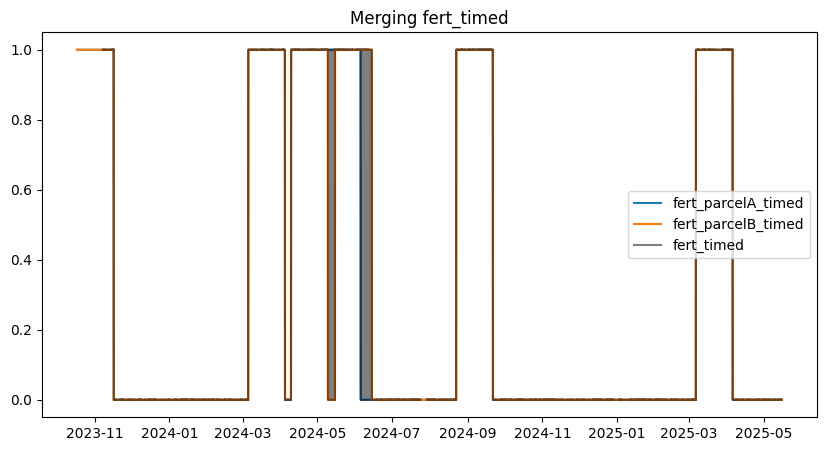

In [9]:
# Merge the split management in one column based on the parcel column
for colA in df.columns:
    if "_parcelA" in colA:
        base = colA.replace("_parcelA", "")
        colB = colA.replace("_parcelA", "_parcelB")
        if colB in df:
            df[base] = np.select(
                [
                    df["parcel"] == "A",
                    df["parcel"] == "B"
                ],
                [
                    df[colA],      # from A
                    df[colB]       # from B
                ],
                default=np.nan   # others → NaN
            )

            # ---- plot comparison before dropping ----
            plt.figure(figsize=(10, 5))
            plt.plot(df.index, df[colA], label=colA)
            plt.plot(df.index, df[colB], label=colB)
            plt.plot(df.index, df[base], label=base, alpha=0.5, color="black")
            plt.title(f"Merging {base}")
            plt.legend()

# LAGGED VARIANTS

Variables for which lagged variants will be calculated:

In [10]:
# Define columns of interest
_list_lag_vars = [
    'NEE_U50_f_reddyproc',
    'GPP_U50_f_reddyproc','Reco_U50_reddyproc',
    'prec',
    'ta',
    'ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 
    'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG'
]
_list_lag_vars

['NEE_U50_f_reddyproc',
 'GPP_U50_f_reddyproc',
 'Reco_U50_reddyproc',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG']

Calculate the lagged variants

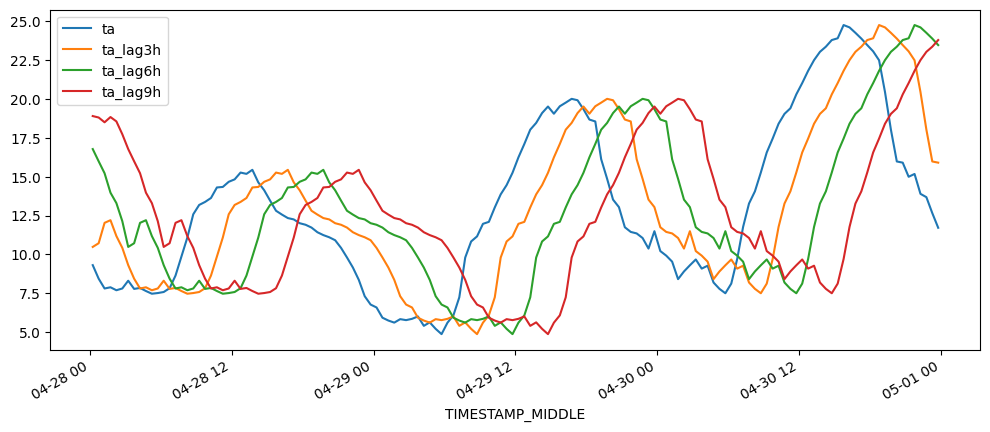

In [11]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Create lagged variants
for v in _list_lag_vars:
    for lag in intervals:
        lag_adjusted = int(lag/time_res)
        if lag_adjusted > 0:
            var_lag = f'{v}_lag{lag}h'
            df[var_lag] = df[v].shift(lag_adjusted)

# Plot the lag vars for TA
indat = df[[c for c in df.columns if 'ta' in c]]
indat = indat.loc['2024-04-28':'2024-04-30']
indat.plot(x_compat=True, figsize=(12, 5));

# ROLLING VARIANTS

Variables for which rolling variants will be calculated:

In [12]:
# Define columns of interest
_list_rolling_vars = [c for c in df.columns if c.startswith(tuple(_list_lag_vars))]
_list_rolling_vars

['NEE_U50_f_reddyproc',
 'GPP_U50_f_reddyproc',
 'Reco_U50_reddyproc',
 'prec',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'NEE_U50_f_reddyproc_lag3h',
 'NEE_U50_f_reddyproc_lag6h',
 'NEE_U50_f_reddyproc_lag9h',
 'GPP_U50_f_reddyproc_lag3h',
 'GPP_U50_f_reddyproc_lag6h',
 'GPP_U50_f_reddyproc_lag9h',
 'Reco_U50_reddyproc_lag3h',
 'Reco_U50_reddyproc_lag6h',
 'Reco_U50_reddyproc_lag9h',
 'prec_lag3h',
 'prec_lag6h',
 'prec_lag9h',
 'ta_lag3h',
 'ta_lag6h',
 'ta_lag9h',
 'ts_0.05_gfXG_lag3h',
 'ts_0.05_gfXG_lag6h',
 'ts_0.05_gfXG_lag9h',
 'ts_0.15_gfXG_lag3h',
 'ts_0.15_gfXG_lag6h',
 'ts_0.15_gfXG_lag9h',
 'ts_0.3_gfXG_lag3h',
 'ts_0.3_gfXG_lag6h',
 'ts_0.3_gfXG_lag9h',
 'wfps_0.05_gfXG_lag3h',
 'wfps_0.05_gfXG_lag6h',
 'wfps_0.05_gfXG_lag9h',
 'wfps_0.15_gfXG_lag3h',
 'wfps_0.15_gfXG_lag6h',
 'wfps_0.15_gfXG_lag9h',
 'wfps_0.3_gfXG_lag3h',
 'wfps_0.3_gfXG_lag6h',
 'wfps_0.3_gfXG_lag9h']

Calculate the rolling variants

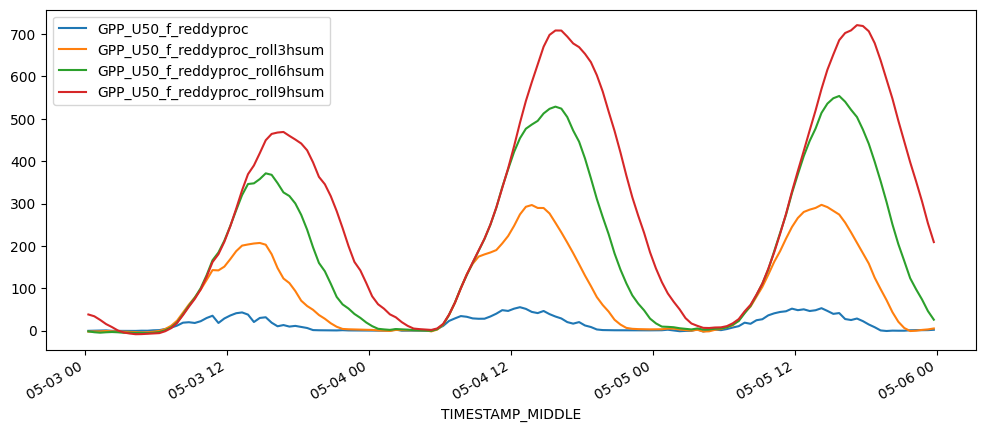

In [13]:
# Define time intervals
intervals = [3, 6, 9] # in hours

# Time resolution of the dataframe
time_res = 0.5

# Define the type of aggregations we will apply
aggtypes_default = ['mean']
aggtypes_sum = ['sum'] # for 'prec', 'GPP', 'Reco', 'NEE'


# Create rolling variants
for v in _list_rolling_vars:
    # Determine aggregation type
    aggtypes = aggtypes_sum if v.startswith(('prec', 'GPP', 'Reco', 'NEE')) else aggtypes_default
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            for agg in aggtypes:
                var_roll = f'{v}_roll{interval}h{agg}'
                df[var_roll] = df[v].rolling(interval_adjusted, min_periods=1).agg(agg)
                df = df.copy()

# Plot the lag vars for GPP
indat = df[[c for c in df.columns if c.startswith('GPP') and 'lag' not in c]]
indat = indat.loc['2024-05-03':'2024-05-05']
indat.plot(x_compat=True, figsize=(12, 5));

# RATE OF CHANGE

Used for WFPS and TS

In [14]:
# define columns of interest
_list_diff_vars = [col for col in df.columns if ('ts' in col or 'wfps' in col) and ('roll' not in col and 'lag' not in col)]

print(f'We calculate the rate of change for these variables: {_list_diff_vars}')

We calculate the rate of change for these variables: ['ts_0.05_gfXG', 'ts_0.15_gfXG', 'ts_0.3_gfXG', 'wfps_0.05_gfXG', 'wfps_0.15_gfXG', 'wfps_0.3_gfXG']


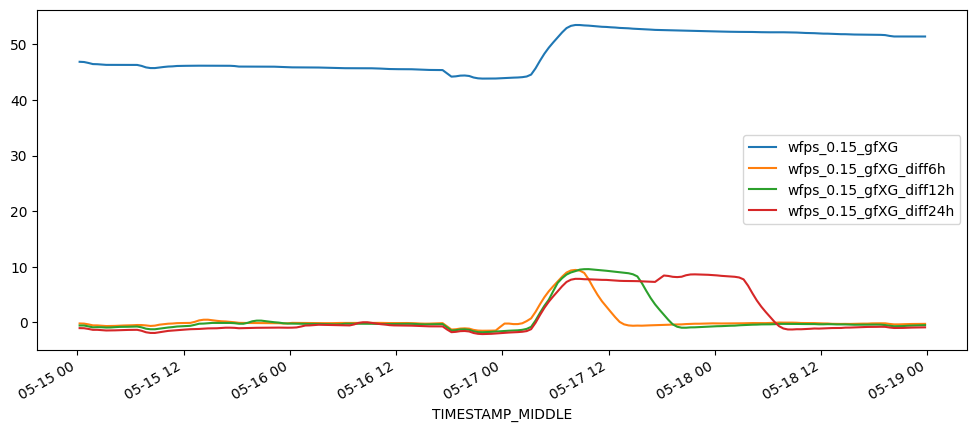

In [15]:
# Define interval of records for the difference calculation
intervals = [6, 12, 24] # in hours


# Time resolution of the dataframe
time_res = 0.5

# Create the variants
for v in _list_diff_vars:
    for interval in intervals:
        interval_adjusted = int(interval/time_res)
        if interval_adjusted > 0:
            var_diff = f'{v}_diff{interval}h'
            df[var_diff] = df[v].diff(periods=interval_adjusted)


# Plot the lag vars for wfps_0.15

indat = df[[c for c in df.columns if c.startswith('wfps_0.15') and 'lag' not in c and 'roll' not in c]]
indat = indat.loc['2024-05-15':'2024-05-18']
indat.plot(x_compat=True, figsize=(12, 5));

# EXPORT DATA

## CHECK DATAFRAME

In [16]:
df

,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 12:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 13:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 13:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 14:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,15.833333,22.0,0.285270,...,0.564180,1.105808,0.251504,0.137646,0.269348,-0.182687,-1.770683,-2.475835,-0.177535,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,15.733333,23.0,0.289417,...,-0.058895,1.185266,0.415243,-0.006586,0.174141,-0.309516,-4.491630,-2.066168,-1.321539,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.200000,24.0,0.404542,...,-0.417110,0.829382,0.121118,0.319431,0.265461,-0.070498,-5.166902,-3.647422,-1.775911,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567


Check what columns are contained in the final dataset

In [17]:
print(f'Dataframe contains {len(df.columns)} columns: {sorted(df.columns)}')

Dataframe contains 231 columns: ['FCH4_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF0', 'FN2O_L3.3_CUT_50_QCF', 'FN2O_L3.3_CUT_50_QCF0', 'GPP_U50_f_reddyproc', 'GPP_U50_f_reddyproc_lag3h', 'GPP_U50_f_reddyproc_lag3h_roll3hsum', 'GPP_U50_f_reddyproc_lag3h_roll6hsum', 'GPP_U50_f_reddyproc_lag3h_roll9hsum', 'GPP_U50_f_reddyproc_lag6h', 'GPP_U50_f_reddyproc_lag6h_roll3hsum', 'GPP_U50_f_reddyproc_lag6h_roll6hsum', 'GPP_U50_f_reddyproc_lag6h_roll9hsum', 'GPP_U50_f_reddyproc_lag9h', 'GPP_U50_f_reddyproc_lag9h_roll3hsum', 'GPP_U50_f_reddyproc_lag9h_roll6hsum', 'GPP_U50_f_reddyproc_lag9h_roll9hsum', 'GPP_U50_f_reddyproc_roll3hsum', 'GPP_U50_f_reddyproc_roll6hsum', 'GPP_U50_f_reddyproc_roll9hsum', 'NEE_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF0', 'NEE_U50_f_reddyproc', 'NEE_U50_f_reddyproc_lag3h', 'NEE_U50_f_reddyproc_lag3h_roll3hsum', 'NEE_U50_f_reddyproc_lag3h_roll6hsum', 'NEE_U50_f_reddyproc_lag3h_roll9hsum', 'NEE_U50_f_reddyproc_lag6h', 'NEE_U50_f_reddyproc_lag6h_roll3hsum', 'NEE_U50_f_reddyproc_lag6

Check the timestamp

In [18]:
# Generate the complete timestamp range
start_date = df.index.min()
end_date = df.index.max()
complete_timestamp = pd.date_range(start=start_date, end=end_date, freq='30min')

# Compare the complete range with the dataframe's index
missing_timestamps = complete_timestamp.difference(df.index)
duplicate_timestamps = df.index[df.index.duplicated()]

# Output the duplicate and missing timestamps
if not duplicate_timestamps.empty:
    print("Duplicate Timestamps:")
    print(duplicate_timestamps)
else:
    print("No duplicate timestamps found.")

if not missing_timestamps.empty:
    print("Missing Timestamps:")
    print(missing_timestamps)
else:
    print("No missing timestamps found.")

# Check if the timestamp is complete and has no duplicates
if duplicate_timestamps.empty and missing_timestamps.empty:
    print("The timestamp index is complete and has no duplicates.")
else:
    print("The timestamp index has issues.")

No duplicate timestamps found.
No missing timestamps found.
The timestamp index is complete and has no duplicates.


## SAVE FILES

In [19]:
filename = "81.1_GapFillingDataset"
df.to_csv(f"{filename}.csv", index=True)
save_parquet(data=df, filename=filename)

Saved file 81.1_GapFillingDataset.parquet (1.627 seconds).


'81.1_GapFillingDataset.parquet'

# **End of notebook**

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-09-19 10:21:10
